In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import plotly.express as px
import plotly.graph_objects as go


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:", df.shape)



Dataset Shape After Removing Duplicates: (283726, 31)


In [7]:
# Check data types
print("\nData Types:")
print(df.dtypes)



Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [6]:
"""DESCRIPTIVE STATISTICS"""

print("\nStatistical Summary:")
print(df.describe())

# Average transaction amount
avg_amount = df["Amount"].mean()
print("\nAverage Transaction Amount:", avg_amount)

# Fraud vs Normal transaction count
fraud_count = df["Class"].value_counts()

print("\nFraud vs Normal Transactions:")
print(fraud_count)

"""FRAUD BEHAVIOR ANALYSIS"""

normal_transactions = df[df["Class"] == 0]
fraud_transactions = df[df["Class"] == 1]

print("\nNormal Transactions:")
print(normal_transactions.describe())

print("\nFraud Transactions:")
print(fraud_transactions.describe())

"""GROUP BASED ANALYSIS"""

# Average amount by class
group_analysis = df.groupby("Class")["Amount"].mean()

print("\nAverage Transaction Amount by Class:")
print(group_analysis)

"""RELATIONSHIP ANALYSIS"""

correlation = df.corr()


Statistical Summary:
                Time             V1             V2             V3  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean    94811.077600       0.005917      -0.004135       0.001613   
std     47481.047891       1.948026       1.646703       1.508682   
min         0.000000     -56.407510     -72.715728     -48.325589   
25%     54204.750000      -0.915951      -0.600321      -0.889682   
50%     84692.500000       0.020384       0.063949       0.179963   
75%    139298.000000       1.316068       0.800283       1.026960   
max    172792.000000       2.454930      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean       -0.002966       0.001828      -0.001139       0.001801   
std         1.414184       1.377008       1.331931       1.227664   
min        -5.683171    -113.743307     -26.160506     -43.557242   
25%        

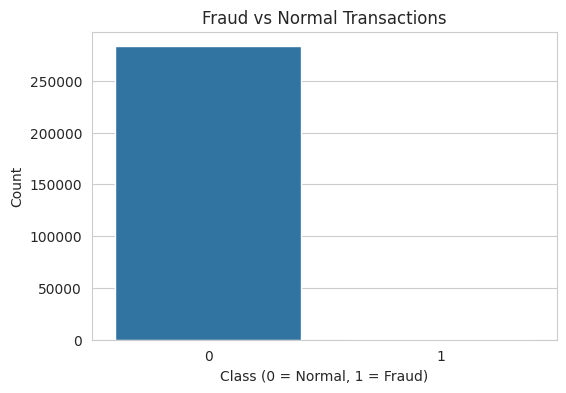

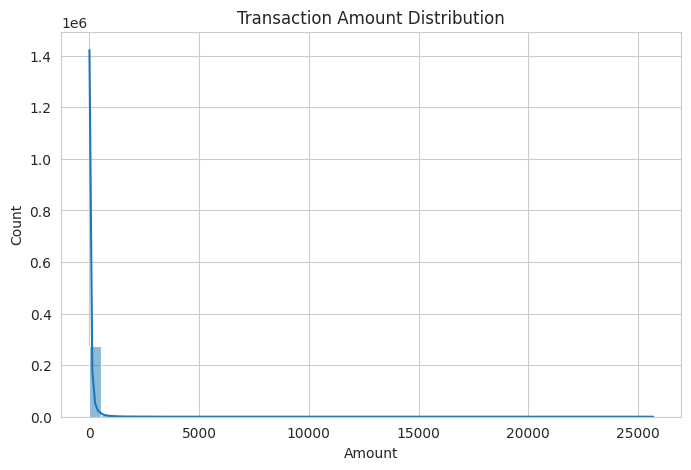

In [8]:
"""DATA VISUALIZATION"""

sns.set_style("whitegrid")

"""Fraud Distribution"""

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

"""Transaction Amount Distribution"""

plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

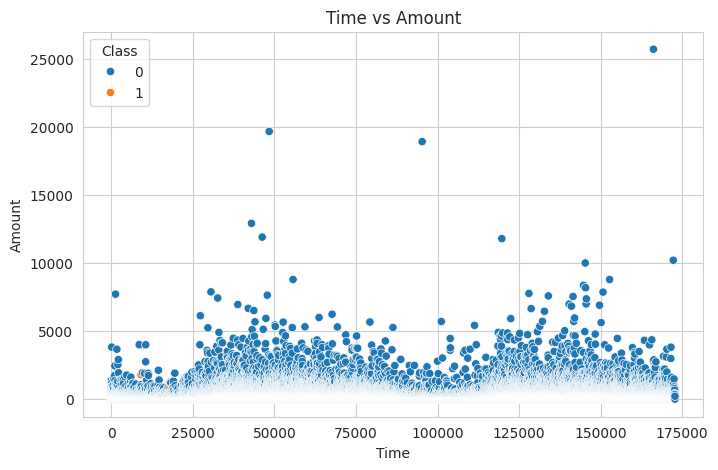

In [9]:
"""Scatter Plot"""

plt.figure(figsize=(8,5))
sns.scatterplot(x='Time', y='Amount', hue='Class', data=df)
plt.title("Time vs Amount")
plt.show()


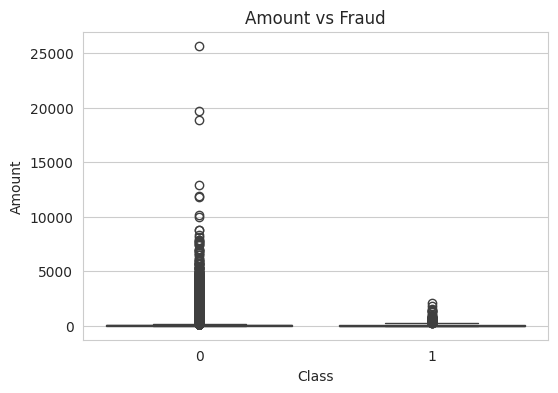

In [10]:
"""Box Plot"""

plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount vs Fraud")
plt.show()

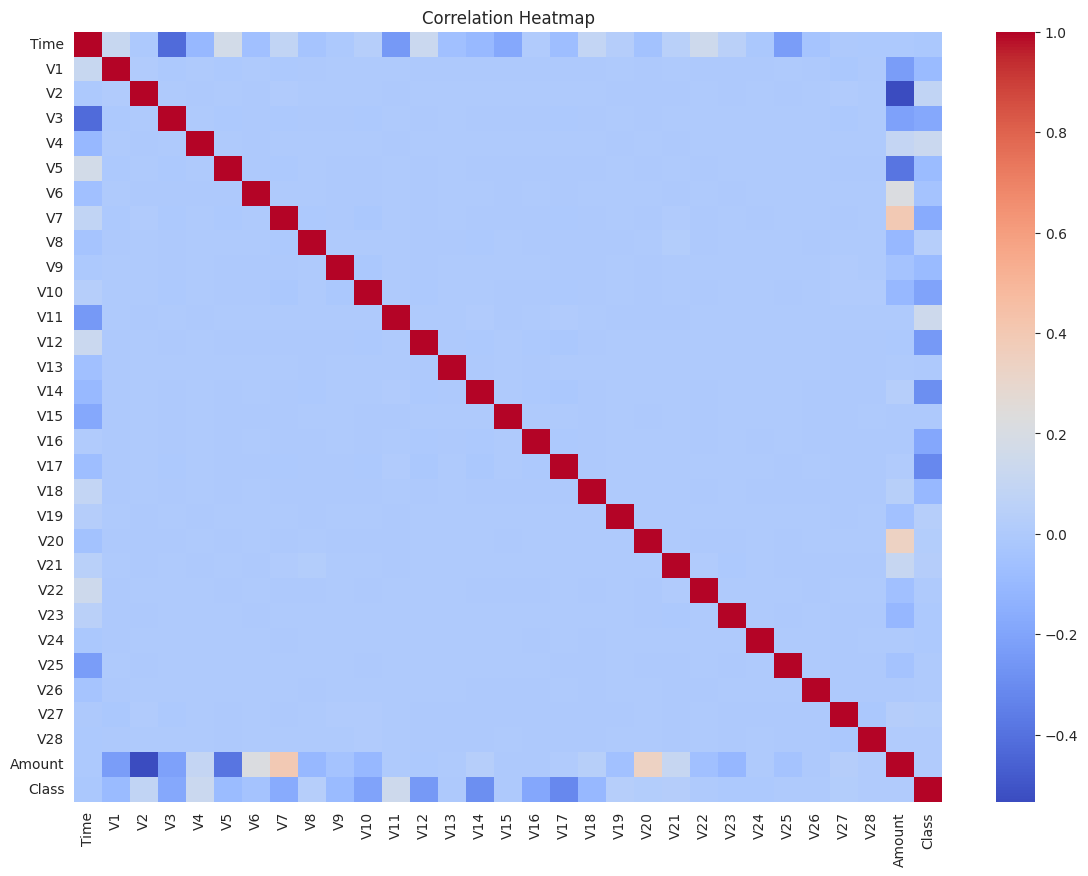

In [12]:
"""Correlation Heatmap"""

plt.figure(figsize=(14,10))
sns.heatmap(correlation, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [11]:
"""Risk Analysis"""

def risk_level(amount):
    if amount < 100:
        return "Low Risk"
    elif amount < 1000:
        return "Medium Risk"
    else:
        return "High Risk"

df["Risk_Level"] = df["Amount"].apply(risk_level)

print("\nRisk Level Distribution:")
print(df["Risk_Level"].value_counts())



Risk Level Distribution:
Risk_Level
Low Risk       226450
Medium Risk     54212
High Risk        3064
Name: count, dtype: int64


In [13]:
"""LINEAR REGRESSION MODEL"""

# Independent Variables
X = df[['Time']]

# Dependent Variable
y = df['Amount']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


Model Evaluation
R2 Score: 0.00015552801701912422
Mean Squared Error: 58643.98795669793


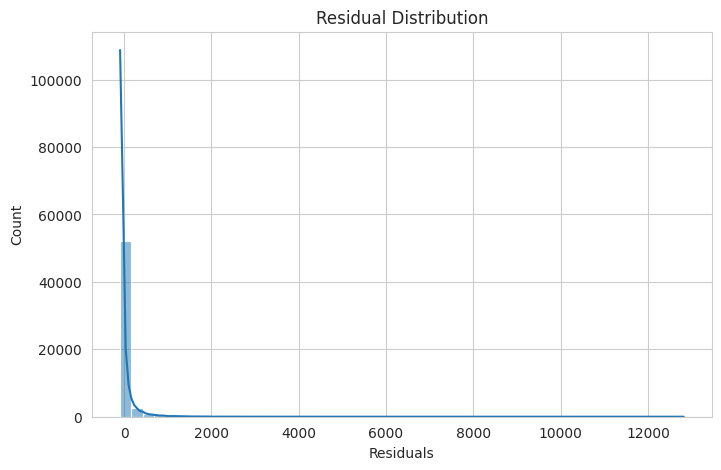

In [14]:
"""MODEL EVALUATION"""

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nModel Evaluation")
print("R2 Score:", r2)
print("Mean Squared Error:", mse)

"""RESIDUAL ANALYSIS"""

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()


In [15]:
"""INTERACTIVE DASHBOARD"""

# Fraud Distribution Chart
fig1 = px.histogram(
    df,
    x="Class",
    title="Fraud vs Normal Transactions",
    labels={"Class": "Transaction Type"}
)

fig1.show()

# Transaction Amount Trend
fig2 = px.scatter(
    df,
    x="Time",
    y="Amount",
    color="Class",
    title="Transaction Amount Over Time"
)

fig2.show()

In [16]:
# Risk Level Chart
fig3 = px.pie(
    df,
    names="Risk_Level",
    title="Risk Level Distribution"
)

fig3.show()

# Correlation Heatmap
fig4 = go.Figure(
    data=go.Heatmap(
        z=correlation.values,
        x=correlation.columns,
        y=correlation.columns,
        colorscale='Viridis'
    )
)

fig4.update_layout(title="Correlation Heatmap")
fig4.show()

In [19]:
""" INSIGHTS & CONCLUSION"""

print("\nPROJECT INSIGHTS")
print("---------------------------")
print("1. Fraud transactions are very low compared to normal transactions.")
print("2. Transaction amount plays an important role in fraud detection.")
print("3. Some features show strong correlations with fraudulent activity.")
print("4. High-risk transactions can be identified using amount patterns.")
print("5. Dashboard visualizations help understand fraud behavior easily.")

print("\nThis Project Was Completed Successfully.")


PROJECT INSIGHTS
---------------------------
1. Fraud transactions are very low compared to normal transactions.
2. Transaction amount plays an important role in fraud detection.
3. Some features show strong correlations with fraudulent activity.
4. High-risk transactions can be identified using amount patterns.
5. Dashboard visualizations help understand fraud behavior easily.

This Project Was Completed Successfully.
